In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import os

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 5)


In [2]:
LOG_PATH = "../data/raw/HDFS.log"
LABEL_PATH = "../data/raw/anomaly_label.csv"

for path in [LOG_PATH, LABEL_PATH]:
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"Found: {path} ({size_mb:.1f} MB)")
    else:
        print(f"MISSING: {path}")

Found: ../data/raw/HDFS.log (1504.9 MB)
Found: ../data/raw/anomaly_label.csv (17.8 MB)


In [3]:
def parse_hdfs_line(line):
    """Parse one HDFS log line into structured fields."""
    match = re.match(
        r'(\d{6})\s+(\d{6})\s+(\d+)\s+(\w+)\s+([\w\.\$]+):\s*(.*)',
        line.strip()
    )
    if match:
        date, time_str, pid, level, component, message = match.groups()
        block_match = re.search(r'(blk_-?\d+)', message)
        block_id = block_match.group(1) if block_match else None
        return {
            'date': date,
            'time': time_str,
            'pid': int(pid),
            'level': level,
            'component': component,
            'message': message,
            'block_id': block_id,
        }
    return None

print("Parsing first 100,000 lines...")
parsed_logs = []
with open(LOG_PATH, 'r') as f:
    for i, line in enumerate(f):
        if i >= 100_000:
            break
        result = parse_hdfs_line(line)
        if result:
            parsed_logs.append(result)

df = pd.DataFrame(parsed_logs)
print(f"Parsed {len(df):,} lines")
print(f"Columns: {list(df.columns)}")
df.head(10)

Parsing first 100,000 lines...
Parsed 100,000 lines
Columns: ['date', 'time', 'pid', 'level', 'component', 'message', 'block_id']


,date,time,pid,level,component,message,block_id
0,081109,203518,143,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906
1,081109,203518,35,INFO,dfs.FSNamesystem,BLOCK* NameSystem.allocateBlock: /mnt/hadoop/m...,blk_-1608999687919862906
2,081109,203519,143,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906
3,081109,203519,145,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906
4,081109,203519,145,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_-1608999687919...,blk_-1608999687919862906
5,081109,203519,145,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_-1608999687919...,blk_-1608999687919862906
6,081109,203519,145,INFO,dfs.DataNode$PacketResponder,Received block blk_-1608999687919862906 of siz...,blk_-1608999687919862906
7,081109,203519,145,INFO,dfs.DataNode$PacketResponder,Received block blk_-1608999687919862906 of siz...,blk_-1608999687919862906
8,081109,203519,147,INFO,dfs.DataNode$PacketResponder,PacketResponder 0 for block blk_-1608999687919...,blk_-1608999687919862906
9,081109,203519,147,INFO,dfs.DataNode$PacketResponder,Received block blk_-1608999687919862906 of siz...,blk_-1608999687919862906


In [4]:
print(f"Total lines parsed: {len(df):,}")
print(f"Unique block IDs: {df['block_id'].nunique():,}")
print(f"Lines with block ID: {df['block_id'].notna().sum():,} ({df['block_id'].notna().mean():.1%})")
print(f"Lines without block ID: {df['block_id'].isna().sum():,}")

print(f"\n--- Log Levels ---")
print(df['level'].value_counts())

print(f"\n--- Top 10 Components ---")
print(df['component'].value_counts().head(10))


Total lines parsed: 100,000
Unique block IDs: 7,940
Lines with block ID: 100,000 (100.0%)
Lines without block ID: 0

--- Log Levels ---
level
INFO    100000
Name: count, dtype: int64

--- Top 10 Components ---
component
dfs.DataNode$PacketResponder    44450
dfs.FSNamesystem                30253
dfs.DataNode$DataXceiver        24111
dfs.DataBlockScanner             1088
dfs.DataNode                       26
dfs.DataNode$DataTransfer          25
dfs.DataNode$BlockReceiver         25
dfs.FSDataset                      22
Name: count, dtype: int64


In [5]:
print("--- Top 15 Message Patterns (first 80 chars) ---\n")

msg_patterns = df['message'].str[:80].value_counts().head(15)

for i, (msg, count) in enumerate(msg_patterns.items(), 1):
    print(f"  {i:2d}. [{count:>6,}x]  {msg}")
    

--- Top 15 Message Patterns (first 80 chars) ---

   1. [ 7,935x]  BLOCK* NameSystem.allocateBlock: /user/root/rand/_temporary/_task_200811092030_0
   2. [   132x]  BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.66.63:50010 is added 
   3. [   131x]  BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.126.83:50010 is added
   4. [   128x]  BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.215.16:50010 is added
   5. [   128x]  BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.250.14.196:50010 is added
   6. [   124x]  BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.39.192:50010 is added
   7. [   124x]  BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.195.70:50010 is added
   8. [   123x]  BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.250.19.16:50010 is added 
   9. [   123x]  BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.199.86:50010 is added
  10. [   123x]  BLOCK* NameSystem.addStoredBlock: blockMap updated:

In [6]:
labels = pd.read_csv(LABEL_PATH)
print(f"Shape: {labels.shape}")
print(f"Columns: {list(labels.columns)}")
print(f"\nFirst 5 rows:")
print(labels.head())
print(f"\n--- Label Distribution ---")
print(labels['Label'].value_counts())
print(f"\nAnomaly rate: {(labels['Label'] == 'Anomaly').mean():.2%}")

Shape: (575061, 2)
Columns: ['BlockId', 'Label']

First 5 rows:
                    BlockId    Label
0  blk_-1608999687919862906   Normal
1   blk_7503483334202473044   Normal
2  blk_-3544583377289625738  Anomaly
3  blk_-9073992586687739851   Normal
4   blk_7854771516489510256   Normal

--- Label Distribution ---
Label
Normal     558223
Anomaly     16838
Name: count, dtype: int64

Anomaly rate: 2.93%


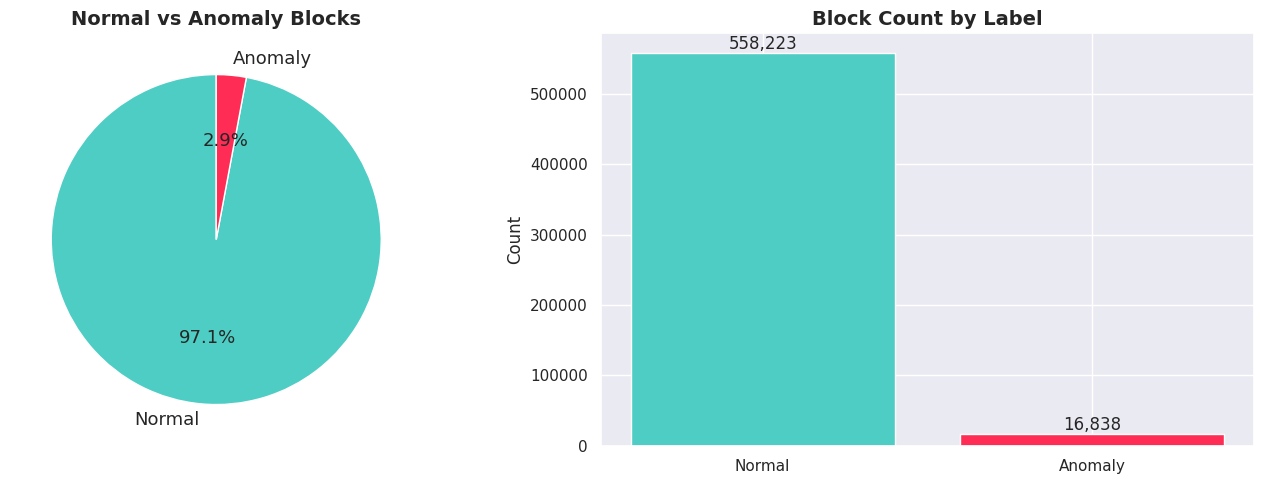

Saved: docs/images/01_anomaly_distribution.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_counts = labels['Label'].value_counts()

axes[0].pie(
    label_counts,
    labels=label_counts.index,
    autopct='%1.1f%%',
    colors=['#4ecdc4', '#ff2d55'],
    startangle=90,
    textprops={'fontsize': 13}
)
axes[0].set_title('Normal vs Anomaly Blocks', fontweight='bold', fontsize=14)

axes[1].bar(
    label_counts.index,
    label_counts.values,
    color=['#4ecdc4', '#ff2d55']
)
axes[1].set_title('Block Count by Label', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Count')

for i, (label, count) in enumerate(label_counts.items()):
    axes[1].text(i, count + 5000, f'{count:,}', ha='center', fontsize=12)

plt.tight_layout()
plt.savefig('../docs/images/01_anomaly_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: docs/images/01_anomaly_distribution.png")

In [8]:
block_stats = df.groupby('block_id').agg(
    num_lines=('message', 'size'),
    num_components=('component', 'nunique'),
    unique_messages=('message', 'nunique'),
).reset_index()

block_stats = block_stats.merge(labels, left_on='block_id', right_on='BlockId', how='inner')

print(f"Blocks matched with labels: {len(block_stats):,}")
print(f"\n--- Normal blocks ---")
print(block_stats[block_stats['Label'] == 'Normal']['num_lines'].describe().round(1))
print(f"\n--- Anomaly blocks ---")
print(block_stats[block_stats['Label'] == 'Anomaly']['num_lines'].describe().round(1))

Blocks matched with labels: 7,940

--- Normal blocks ---
count    7627.0
mean       12.7
std         3.4
min         1.0
25%        13.0
50%        13.0
75%        13.0
max       249.0
Name: num_lines, dtype: float64

--- Anomaly blocks ---
count    313.0
mean       9.7
std       13.0
min        1.0
25%        4.0
50%       13.0
75%       13.0
max      216.0
Name: num_lines, dtype: float64


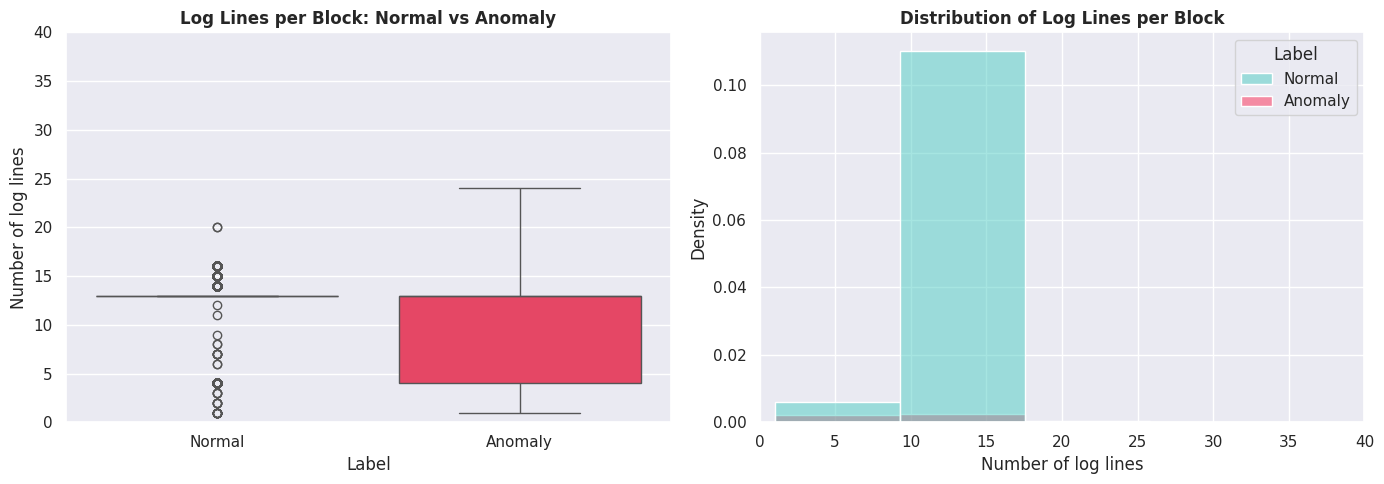

Saved: docs/images/01_block_comparison.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=block_stats, x='Label', y='num_lines',
    hue='Label',
    palette={'Normal': '#4ecdc4', 'Anomaly': '#ff2d55'},
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Log Lines per Block: Normal vs Anomaly', fontweight='bold')
axes[0].set_ylim(0, 40)
axes[0].set_ylabel('Number of log lines')

sns.histplot(
    data=block_stats, x='num_lines', hue='Label',
    palette={'Normal': '#4ecdc4', 'Anomaly': '#ff2d55'},
    bins=30, ax=axes[1], stat='density'
)
axes[1].set_title('Distribution of Log Lines per Block', fontweight='bold')
axes[1].set_xlim(0, 40)
axes[1].set_xlabel('Number of log lines')

plt.tight_layout()
plt.savefig('../docs/images/01_block_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: docs/images/01_block_comparison.png")

In [14]:
print("=" * 60)
print("PHASE 1 COMPLETE — Data Exploration Summary")
print("=" * 60)
print(f"""
DATASET: HDFS logs from 203-node Hadoop cluster (LogHub)

KEY FINDINGS:
  1. Total log lines: 11,175,629 (we sampled 100K)
  2. Total blocks: 575,061
  3. Labels: 558,223 Normal | 16,838 Anomaly (2.93%)
  4. All sampled logs are INFO level — anomalies are
     hidden in event SEQUENCE, not in log level
  5. Normal blocks: consistently ~13 lines (std=3.4)
  6. Anomaly blocks: variable length (std=13.0),
     many are short (failed early) or long (retries)

IMPLICATION:
  - Keyword filtering (grep ERROR) would miss 100% of anomalies
  - Need sequence-based ML to detect pattern deviations
  - Class imbalance (97:3) requires F1-score, not accuracy

NEXT STEP: Phase 2 — Log parsing with Drain3
  - Convert raw messages to event templates
  - Build event sequences per block
  - Prepare input for DeepLog LSTM model
""")

PHASE 1 COMPLETE — Data Exploration Summary

DATASET: HDFS logs from 203-node Hadoop cluster (LogHub)

KEY FINDINGS:
  1. Total log lines: 11,175,629 (we sampled 100K)
  2. Total blocks: 575,061
  3. Labels: 558,223 Normal | 16,838 Anomaly (2.93%)
  4. All sampled logs are INFO level — anomalies are
     hidden in event SEQUENCE, not in log level
  5. Normal blocks: consistently ~13 lines (std=3.4)
  6. Anomaly blocks: variable length (std=13.0),
     many are short (failed early) or long (retries)

IMPLICATION:
  - Keyword filtering (grep ERROR) would miss 100% of anomalies
  - Need sequence-based ML to detect pattern deviations
  - Class imbalance (97:3) requires F1-score, not accuracy

NEXT STEP: Phase 2 — Log parsing with Drain3
  - Convert raw messages to event templates
  - Build event sequences per block
  - Prepare input for DeepLog LSTM model

